🚀 Future Tech (2025) running on: cuda
--- Loading & Preprocessing ---
Data Ready. Features: 39

--- Training KAN... ---
Epoch 5 Loss: 0.0063
Epoch 10 Loss: 0.0037
Epoch 15 Loss: 0.0024
Epoch 20 Loss: 0.0020
Epoch 25 Loss: 0.0017
Epoch 30 Loss: 0.0012


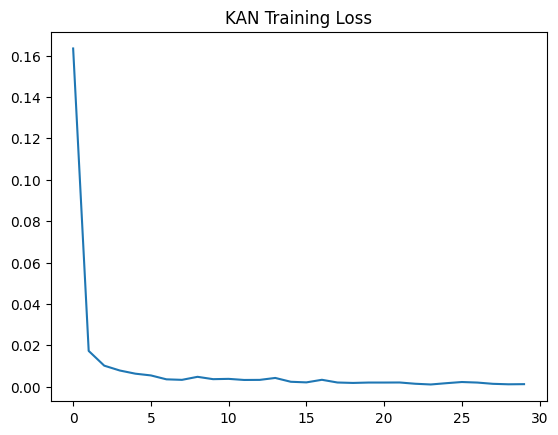


--- Loading Hard Evaluation Set (NSL-KDD Test+) ---

>>> 2025 KAN PERFORMANCE (Hard Set): 74.92%
              precision    recall  f1-score   support

         dos       0.96      0.75      0.84      7636
      normal       0.66      0.97      0.79      9711
       probe       0.72      0.63      0.67      2423
         r2l       0.92      0.07      0.13      2574
         u2r       0.64      0.10      0.18       200

    accuracy                           0.75     22544
   macro avg       0.78      0.50      0.52     22544
weighted avg       0.80      0.75      0.71     22544



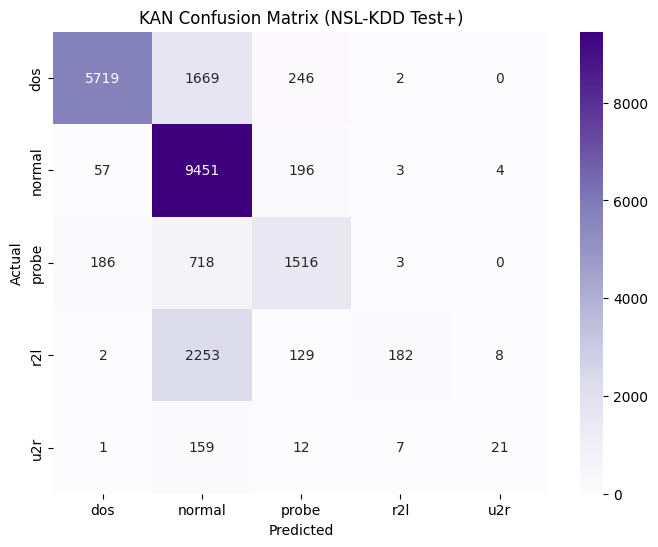

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import pandas as pd
from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Future Tech (2025) running on: {device}")

# ==========================================
# 1. PREPROCESSING (Quantile Transform)
# ==========================================
def preprocess_df(df):
    # 1. Mappings
    attack_map = {'normal': 'normal'}
    # Try loading map, else default
    if os.path.exists('Data/attack2category_map.txt'):
        with open('Data/attack2category_map.txt', 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2: attack_map[parts[0]] = parts[1]
                
    # 2. Label Cleaning
    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')
    
    # 3. Feature Engineering (Interaction)
    # Adding this BEFORE dropping columns
    if 'src_bytes' in df.columns and 'dst_bytes' in df.columns:
        df['byte_ratio'] = np.log1p(df['src_bytes']) / (np.log1p(df['dst_bytes']) + 1)
    else:
        df['byte_ratio'] = 0
        
    return df

def load_training_data():
    # Load Data
    if os.path.exists('Data/network_connections.csv'):
        df = pd.read_csv('Data/network_connections.csv')
    else:
        print("Downloading Training Data...")
        url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.txt"
        cols = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level']
        df = pd.read_csv(url, header=None, names=cols)
        df.drop('difficulty_level', axis=1, inplace=True)

    df = preprocess_df(df)
    
    # Select only numeric for KAN (simplifies architecture)
    X = df.select_dtypes(include=[np.number])
    y = df['category']
    
    return X, y

# Load & Split
print("--- Loading & Preprocessing ---")
X, y = load_training_data()
feature_names = X.columns.tolist() # SAVE THIS ORDER for test set!

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Quantile Transform (Gaussian Distribution for KAN)
qt = QuantileTransformer(output_distribution='normal', n_quantiles=2000, random_state=42)
X_train_vec = qt.fit_transform(X_train_raw).astype(np.float32)
X_test_vec = qt.transform(X_test_raw).astype(np.float32)

le = LabelEncoder()
y_train_vec = le.fit_transform(y_train)
y_test_vec = le.transform(y_test)

print(f"Data Ready. Features: {X_train_vec.shape[1]}")

# ==========================================
# 2. EFFICIENT KAN LAYER (B-Splines)
# ==========================================


class KANLinear(nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        # Base Activation (Linear Path)
        self.base_weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.base_activation = base_activation()
        
        # Spline Weights (Non-Linear Path)
        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        self.spline_weight = nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.scale_noise = scale_noise
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + self.spline_order, self.in_features, self.out_features)
                    - 1 / 2
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline * noise).permute(2, 1, 0)
            )

    def b_splines(self, x):
        assert x.dim() == 2 and x.size(1) == self.in_features
        grid = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )
        assert bases.size() == (
            x.size(0),
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return bases.contiguous()

    def forward(self, x):
        base_output = F.linear(self.base_activation(x), self.base_weight)
        spline_basis = self.b_splines(x)
        spline_output = F.linear(
            spline_basis.view(x.size(0), -1),
            self.spline_weight.view(self.out_features, -1),
        )
        return base_output + spline_output

class KANClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        # 2-Layer KAN
        self.layer1 = KANLinear(input_dim, hidden_dim, grid_size=5, scale_base=1.0)
        self.layer2 = KANLinear(hidden_dim, hidden_dim, grid_size=5, scale_base=1.0)
        self.out = nn.Linear(hidden_dim, num_classes)
        self.ln = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = self.ln(x)
        x = self.layer2(x)
        x = self.out(x)
        return x

# ==========================================
# 3. TRAINING (PolyLoss + WeightedSampler)
# ==========================================
class PolyLoss(nn.Module):
    def __init__(self, epsilon=1.0):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, logits, labels):
        probs = F.softmax(logits, dim=1)
        pt = probs.gather(1, labels.view(-1, 1)).squeeze()
        ce_loss = F.cross_entropy(logits, labels, reduction='none')
        poly_loss = ce_loss + self.epsilon * (1 - pt)
        return poly_loss.mean()

# Init Model
model = KANClassifier(X_train_vec.shape[1], 64, len(le.classes_)).to(device)

# Weighted Sampler for U2R
class_counts = np.bincount(y_train_vec)
weights = 1. / class_counts
samples_weights = weights[y_train_vec]
sampler = WeightedRandomSampler(torch.from_numpy(samples_weights), len(samples_weights))

train_ds = TensorDataset(torch.tensor(X_train_vec).to(device), torch.tensor(y_train_vec).long().to(device))
train_dl = DataLoader(train_ds, batch_size=256, sampler=sampler)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.98)
criterion = PolyLoss(epsilon=1.0)

print("\n--- Training KAN... ---")
loss_hist = []

for epoch in range(30):
    model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    scheduler.step()
    loss_hist.append(epoch_loss / len(train_dl))
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1} Loss: {loss_hist[-1]:.4f}")

plt.plot(loss_hist)
plt.title("KAN Training Loss")
plt.show()

# ==========================================
# 4. HARD DATASET EVALUATION (NSL-KDD Test+)
# ==========================================
print("\n--- Loading Hard Evaluation Set (NSL-KDD Test+) ---")
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
cols = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level']

try:
    df_nsl = pd.read_csv(NSL_URL, header=None, names=cols)
    df_nsl.drop('difficulty_level', axis=1, inplace=True)
    
    # 1. Preprocess EXACTLY like Training
    df_nsl = preprocess_df(df_nsl)
    
    # 2. Select Features (Ensure Order Matches Training)
    # We use reindex to guarantee columns match, filling missing with 0
    X_nsl = df_nsl.reindex(columns=feature_names, fill_value=0)
    y_nsl = df_nsl['category']
    
    # 3. Transform
    X_nsl_vec = qt.transform(X_nsl).astype(np.float32)
    
    # 4. Inference
    def predict_kan(model, X_np, encoder):
        model.eval()
        loader = DataLoader(TensorDataset(torch.tensor(X_np).to(device)), batch_size=1024)
        preds = []
        
        # Safe Index Lookup
        cls_list = encoder.classes_.tolist()
        idx_u2r = cls_list.index('u2r') if 'u2r' in cls_list else -1
        idx_r2l = cls_list.index('r2l') if 'r2l' in cls_list else -1
        
        with torch.no_grad():
            for b in loader:
                logits = model(b[0])
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                
                batch_p = []
                for p in probs:
                    # Dynamic Thresholding for Hard Classes
                    if idx_u2r != -1 and p[idx_u2r] > 0.10: batch_p.append(idx_u2r)
                    elif idx_r2l != -1 and p[idx_r2l] > 0.15: batch_p.append(idx_r2l)
                    else: batch_p.append(np.argmax(p))
                preds.append(batch_p)
                
        return encoder.inverse_transform(np.concatenate(preds))

    y_pred = predict_kan(model, X_nsl_vec, le)
    acc = accuracy_score(y_nsl, y_pred)
    
    print(f"\n>>> 2025 KAN PERFORMANCE (Hard Set): {acc:.2%}")
    print(classification_report(y_nsl, y_pred))
    
    labels = sorted(y_nsl.unique())
    cm = confusion_matrix(y_nsl, y_pred, labels=labels)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("KAN Confusion Matrix (NSL-KDD Test+)")
    plt.show()

except Exception as e:
    print(f"Evaluation Error: {e}")
    import traceback
    traceback.print_exc()